In [ ]:
import libMilne as MILNE
import numpy as np
import mpmath as mp

mass = 1.0
tau = 1.0
beta = 1.0
SP = 1e-5
mu_T = 0.0

def eps (tau, mass, mu, px, py):
    return np.sqrt(mass**2 + px**2 + py**2 + mu**2/tau**2)

def nf (tau, mass, beta, mu, px, py ):
    return 1/(np.exp(eps(tau, mass, mu, px, py)*beta)+1)

mu_min, mu_max = -10, 10.0
px_min, px_max = -10.0, 10.0
py_min, py_max = -10.0, 10.0

N = 10  # Adjust for speed/resolution

mu_grid = np.linspace(mu_min, mu_max, N)
px_grid = np.linspace(px_min, px_max, N)
py_grid = np.linspace(py_min, py_max, N)

integrand_CAN = np.zeros((N, N, N))
integrand_BEL = np.zeros((N, N, N))

for i, mu in enumerate(mu_grid):
    for j, px in enumerate(px_grid):
        for k, py in enumerate(py_grid):
            integrand_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_energy(
                mass, px, py, mu, tau, beta, SP, mu_T, precision=50
            )))
            integrand_BEL[i, j, k] = float(((2 * mp.pi) ** (-3)*tau) * ( 2 * eps(tau,mass,mu,px,py)) * 2 * nf(tau,mass,beta,mu,px,py))
from scipy.integrate import simpson

result_mu = simpson(integrand_CAN, x=mu_grid, axis=0)
result_px = simpson(result_mu, x=px_grid, axis=0)
E_can = simpson(result_px, x=py_grid, axis=0)

class_mu = simpson(integrand_BEL, x=mu_grid, axis=0)
class_px = simpson(class_mu, x=mu_grid, axis=0)
E_bel = simpson(class_px, x=py_grid, axis=0)

print(f"Integral result SP = {SP}:", E_can)
print("\n")
print(f"Integral result Belinfante :", E_bel)
print(f"Integral result Canonico :", E_can)
print(f"Ratio E_can/E_bel:", E_can/E_bel)

/var/folders/kj/8tgfcy9s5077xt553nx3by6h0000gn/T/ipykernel_7194/2398446780.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_energy(


Integral result SP = 0.0001: 1.0586988034387714


Integral result Belinfante : 1.0586988032638163
Integral result Canonico : 1.0586988034387714
Ratio E_can/E_bel: 1.000000000165255


In [5]:
import libMilne as MILNE
import numpy as np
import mpmath as mp

mass = 1.0
tau = 1.0
beta = 1.0
SP = 0.0001
mu_T = 0.0

def eps (tau, mass, mu, px, py):
    return np.sqrt(mass**2 + px**2 + py**2 + mu**2/tau**2)

def nf (tau, mass, beta, mu, px, py ):
    return 1/(np.exp(eps(tau, mass, mu, px, py)*beta)+1)

mu_min, mu_max = -10, 10.0
px_min, px_max = -10.0, 10.0
py_min, py_max = -10.0, 10.0

N = 10  # Adjust for speed/resolution

mu_grid = np.linspace(mu_min, mu_max, N)
px_grid = np.linspace(px_min, px_max, N)
py_grid = np.linspace(py_min, py_max, N)

integrand_CAN = np.zeros((N, N, N))
integrand_BEL = np.zeros((N, N, N))

for i, mu in enumerate(mu_grid):
    for j, px in enumerate(px_grid):
        for k, py in enumerate(py_grid):
            integrand_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_pressure_L(
                mass, px, py, mu, tau, beta, SP, mu_T, precision=50
            )))
            integrand_BEL[i, j, k] = float(((2 * mp.pi) ** (-3)*tau) * ( 2 * mu **2 /(tau**2 * eps(tau,mass,mu,px,py))) * 2 * nf(tau,mass,beta,mu,px,py))
from scipy.integrate import simpson

result_mu = simpson(integrand_CAN, x=mu_grid, axis=0)
result_px = simpson(result_mu, x=px_grid, axis=0)
E_can = simpson(result_px, x=py_grid, axis=0)

class_mu = simpson(integrand_BEL, x=mu_grid, axis=0)
class_px = simpson(class_mu, x=mu_grid, axis=0)
E_bel = simpson(class_px, x=py_grid, axis=0)

/var/folders/kj/8tgfcy9s5077xt553nx3by6h0000gn/T/ipykernel_14481/1032383814.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_pressure_L(


In [6]:
import libMilne as MILNE
import numpy as np
import mpmath as mp

mass = 1.0
tau = 1.0
beta = 1.0
SP = 0.0001
mu_T = 0.0

def eps (tau, mass, mu, px, py):
    return np.sqrt(mass**2 + px**2 + py**2 + mu**2/tau**2)

def nf (tau, mass, beta, mu, px, py ):
    return 1/(np.exp(eps(tau, mass, mu, px, py)*beta)+1)

mu_min, mu_max = -10, 10.0
px_min, px_max = -10.0, 10.0
py_min, py_max = -10.0, 10.0

N = 10  # Adjust for speed/resolution

mu_grid = np.linspace(mu_min, mu_max, N)
px_grid = np.linspace(px_min, px_max, N)
py_grid = np.linspace(py_min, py_max, N)

integrand_PT_CAN = np.zeros((N, N, N))
integrand_PT_BEL = np.zeros((N, N, N))
for i, mu in enumerate(mu_grid):
    for j, px in enumerate(px_grid):
        for k, py in enumerate(py_grid):
            integrand_PT_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_pressure_T(
                mass, px, py, mu, tau, beta, SP, mu_T, precision=50
            )))
            integrand_PT_BEL[i, j, k] = float(((2 * mp.pi) ** (-3)*tau) * (  (px**2+py**2) /( eps(tau,mass,mu,px,py))) * 2 * nf(tau,mass,beta,mu,px,py))
from scipy.integrate import simpson

result_PT_mu = simpson(integrand_PT_CAN, x=mu_grid, axis=0)
result_PT_px = simpson(result_PT_mu, x=px_grid, axis=0)
PT_can = simpson(result_PT_px, x=py_grid, axis=0)

class_PT_mu = simpson(integrand_PT_BEL, x=mu_grid, axis=0)
class_PT_px = simpson(class_PT_mu, x=mu_grid, axis=0)
PT_bel = simpson(class_PT_px, x=py_grid, axis=0)

print("Transverse Pressure:")
print("--------------------")
print(f"Transverse Pressure Belinfante PT_bel:", PT_bel)
print(f"Transverse Pressure Canonical PT_can:", PT_can)
print(f"Ratio PT_can/PT_bel:", PT_can/PT_bel)

/var/folders/kj/8tgfcy9s5077xt553nx3by6h0000gn/T/ipykernel_14481/975094378.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_PT_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_pressure_T(


Transverse Pressure:
--------------------
Transverse Pressure Belinfante PT_bel: 0.31876186999849265
Transverse Pressure Canonical PT_can: 0.31937322100481524
Ratio PT_can/PT_bel: 1.0019178925206


In [2]:
import libMilne as MILNE
import numpy as np
import mpmath as mp

mass = 1.0
tau = 1.0
beta = 1.0
SP = 0.0001
mu_T = 0.0

def eps (tau, mass, mu, px, py):
    return np.sqrt(mass**2 + px**2 + py**2 + mu**2/tau**2)

def nf (tau, mass, beta, mu, px, py ):
    return 1/(np.exp(eps(tau, mass, mu, px, py)*beta)+1)

mu_min, mu_max = -10, 10.0
px_min, px_max = -10.0, 10.0
py_min, py_max = -10.0, 10.0

N = 10  # Adjust for speed/resolution

mu_grid = np.linspace(mu_min, mu_max, N)
px_grid = np.linspace(px_min, px_max, N)
py_grid = np.linspace(py_min, py_max, N)

integrand_PT_CAN = np.zeros((N, N, N))
integrand_PT_BEL = np.zeros((N, N, N))
for i, mu in enumerate(mu_grid):
    for j, px in enumerate(px_grid):
        for k, py in enumerate(py_grid):
            integrand_PT_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_pressure_T(
                mass, px, py, mu, tau, beta, SP, mu_T, precision=50
            )))
            integrand_PT_BEL[i, j, k] = float(((2 * mp.pi) ** (-3)*tau) * (  (px**2+py**2) /( eps(tau,mass,mu,px,py))) * 2 * nf(tau,mass,beta,mu,px,py))
from scipy.integrate import simpson

result_PT_mu = simpson(integrand_PT_CAN, x=mu_grid, axis=0)
result_PT_px = simpson(result_PT_mu, x=px_grid, axis=0)
PT_can = simpson(result_PT_px, x=py_grid, axis=0)

class_PT_mu = simpson(integrand_PT_BEL, x=mu_grid, axis=0)
class_PT_px = simpson(class_PT_mu, x=mu_grid, axis=0)
PT_bel = simpson(class_PT_px, x=py_grid, axis=0)

print("Transverse Pressure:")
print("--------------------")
print(f"Transverse Pressure Belinfante PT_bel:", PT_bel)
print(f"Transverse Pressure Canonical PT_can:", PT_can)
print(f"Ratio PT_can/PT_bel:", PT_can/PT_bel)

print("\n")
print("Longitudinal Pressure:")
print("--------------------")
print(f"Longitudinal Pressure Belinfante PT_bel:", PL_bel)
print(f"Longitudinal Pressure Canonical PT_can:", PL_can)
print(f"Ratio PL_can/P;_bel:", PL_can/PL_bel)

/var/folders/kj/8tgfcy9s5077xt553nx3by6h0000gn/T/ipykernel_12359/809947085.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_PT_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_pressure_T(


KeyboardInterrupt: 

In [ ]:
#------------------------#  #------------------------#  #------------------------#  #------------------------#
#------------------------#  #------------------------#  #------------------------#  #------------------------#
#------------------------#  #------------------------#  #------------------------#  #------------------------#
#------------------------#  #------------------------#  #------------------------#  #------------------------#
#------------------------#  #------------------------#  #------------------------#  #------------------------#
#------------------------#  #------------------------#  #------------------------#  #------------------------#
#------------------------#  #------------------------#  #------------------------#  #------------------------#
#------------------------#  #------------------------#  #------------------------#  #------------------------#
#------------------------#  #------------------------#  #------------------------#  #------------------------#
#------------------------#  #------------------------#  #------------------------#  #------------------------#

In [ ]:
import libMilne as MILNE
import numpy as np
import mpmath as mp

mass = 1.0
tau = 1.0
beta = 1.0
SP = 1e-5
mu_T = 0.0

def eps (tau, mass, mu, px, py):
    return np.sqrt(mass**2 + px**2 + py**2 + mu**2/tau**2)

def nf (tau, mass, beta, mu, px, py ):
    return 1/(np.exp(eps(tau, mass, mu, px, py)*beta)+1)

mu_min, mu_max = -10.0, 10.0
px_min, px_max = -10.0, 10.0
py_min, py_max = -10.0, 10.0

N = 10  # Adjust for speed/resolution

mu_grid = np.linspace(mu_min, mu_max, N)
px_grid = np.linspace(px_min, px_max, N)
py_grid = np.linspace(py_min, py_max, N)

integrand_PT_CAN = np.zeros((N, N, N))
integrand_PT_BEL = np.zeros((N, N, N))

integrand_PL_CAN = np.zeros((N, N, N))
integrand_PL_BEL = np.zeros((N, N, N))

integrand_E_CAN = np.zeros((N, N, N))
integrand_E_BEL = np.zeros((N, N, N))

for i, mu in enumerate(mu_grid):
    for j, px in enumerate(px_grid):
        for k, py in enumerate(py_grid):
            integrand_PT_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_pressure_T(
                mass, px, py, mu, tau, beta, SP, mu_T, precision=80
            )))
            integrand_PT_BEL[i, j, k] = float(((2 * mp.pi) ** (-3)*tau) * (  (px**2+py**2) /( eps(tau,mass,mu,px,py))) * 2 * nf(tau,mass,beta,mu,px,py))
            integrand_PL_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_pressure_L(
                mass, px, py, mu, tau, beta, SP, mu_T, precision=80
            )))
            integrand_PL_BEL[i, j, k] = float(((2 * mp.pi) ** (-3)*tau) * ( 2 * mu **2 /(tau**2 * eps(tau,mass,mu,px,py))) * 2 * nf(tau,mass,beta,mu,px,py))
            integrand_E_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_energy(
                mass, px, py, mu, tau, beta, SP, mu_T, precision=80
            )))
            integrand_E_BEL[i, j, k] = float(((2 * mp.pi) ** (-3)*tau) * (2*( eps(tau,mass,mu,px,py))) * 2 * nf(tau,mass,beta,mu,px,py))
from scipy.integrate import simpson

result_PT_mu = simpson(integrand_PT_CAN, x=mu_grid, axis=0)
result_PT_px = simpson(result_PT_mu, x=px_grid, axis=0)
PT_can = simpson(result_PT_px, x=py_grid, axis=0)

class_PT_mu = simpson(integrand_PT_BEL, x=mu_grid, axis=0)
class_PT_px = simpson(class_PT_mu, x=mu_grid, axis=0)
PT_bel = simpson(class_PT_px, x=py_grid, axis=0)

result_PL_mu = simpson(integrand_PL_CAN, x=mu_grid, axis=0)
result_PL_px = simpson(result_PL_mu, x=px_grid, axis=0)
PL_can = simpson(result_PL_px, x=py_grid, axis=0)

class_PL_mu = simpson(integrand_PL_BEL, x=mu_grid, axis=0)
class_PL_px = simpson(class_PL_mu, x=mu_grid, axis=0)
PL_bel = simpson(class_PL_px, x=py_grid, axis=0)

result_E_mu = simpson(integrand_E_CAN, x=mu_grid, axis=0)
result_E_px = simpson(result_E_mu, x=px_grid, axis=0)
E_can = simpson(result_E_px, x=py_grid, axis=0)

class_E_mu = simpson(integrand_E_BEL, x=mu_grid, axis=0)
class_E_px = simpson(class_E_mu, x=mu_grid, axis=0)
E_bel = simpson(class_E_px, x=py_grid, axis=0)

print(f"For OMEGA :", SP)

print("\n")
print("Energy Density:")
print(f"Energy Density Belinfante E_bel:", E_bel)
print(f"Energy Density Canonical E_can:", E_can)
print(f"Ratio E_can/E_bel:", E_can/E_bel)

print("\n")
print("Transverse Pressure:")
print("--------------------")
print(f"Transverse Pressure Belinfante PT_bel:", PT_bel)
print(f"Transverse Pressure Canonical PT_can:", PT_can)
print(f"Ratio PT_can/PT_bel:", PT_can/PT_bel)

print("\n")
print("Longitudinal Pressure:")
print("--------------------")
print(f"Longitudinal Pressure Belinfante PT_bel:", PL_bel)
print(f"Longitudinal Pressure Canonical PT_can:", PL_can)
print(f"Ratio PL_can/P;_bel:", PL_can/PL_bel)

print("\n")
print("Anisotropy Factor:")
print("--------------------")
print(f"Anisotropy Factor Belinfante PL_bel/exPT_bel:", PL_bel/PT_bel)
print(f"Anisotropy Factor Canonical PL_can/PL_can:", PL_can/PT_can)

/var/folders/kj/8tgfcy9s5077xt553nx3by6h0000gn/T/ipykernel_12359/522743598.py:39: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_PT_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_pressure_T(
/var/folders/kj/8tgfcy9s5077xt553nx3by6h0000gn/T/ipykernel_12359/522743598.py:43: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_PL_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_pressure_L(
/var/folders/kj/8tgfcy9s5077xt553nx3by6h0000gn/T/ipykernel_12359/522743598.py:47: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_E_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_energy(


For OMEGA : 1e-05


Energy Density:
Energy Density Belinfante E_bel: 1.0586988032638163
Energy Density Canonical E_can: 1.0586988032656213
Ratio E_can/E_bel: 1.0000000000017049


Transverse Pressure:
--------------------
Transverse Pressure Belinfante PT_bel: 0.31876186999849265
Transverse Pressure Canonical PT_can: 0.31876186999953027
Ratio PT_can/PT_bel: 1.0000000000032552


Longitudinal Pressure:
--------------------
Longitudinal Pressure Belinfante PT_bel: 0.3187618699984927
Longitudinal Pressure Canonical PT_can: 0.3187618699988476
Ratio PL_can/P;_bel: 1.0000000000011133


Anisotropy Factor:
--------------------
Anisotropy Factor Belinfante PT_bel: 1.0000000000000002
Anisotropy Factor Canonical PT_can: 0.9999999999978584


In [1]:
import libMilne as MILNE
import numpy as np
import mpmath as mp

mass = 1.0
tau = 1.0
beta = 1.0
SP = 1e-5
mu_T = 0.0

def eps (tau, mass, mu, px, py):
    return np.sqrt(mass**2 + px**2 + py**2 + mu**2/tau**2)

def nf (tau, mass, beta, mu, px, py ):
    return 1/(np.exp(eps(tau, mass, mu, px, py)*beta)+1)

mu_min, mu_max = -10.0, 10.0
px_min, px_max = -10.0, 10.0
py_min, py_max = -10.0, 10.0

N = 10  # Adjust for speed/resolution

mu_grid = np.linspace(mu_min, mu_max, N)
px_grid = np.linspace(px_min, px_max, N)
py_grid = np.linspace(py_min, py_max, N)

integrand_S_CAN = np.zeros((N, N, N))
integrand_PT_BEL = np.zeros((N, N, N))
for i, mu in enumerate(mu_grid):
    for j, px in enumerate(px_grid):
        for k, py in enumerate(py_grid):
            integrand_S_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_Spin(
                mass, px, py, mu, tau, beta, SP, mu_T, precision=50
            )))
from scipy.integrate import simpson

result_S_mu = simpson(integrand_S_CAN, x=mu_grid, axis=0)
result_S_px = simpson(result_S_mu, x=px_grid, axis=0)
S_can = simpson(result_S_px, x=py_grid, axis=0)


print("Spin Density:")
print("--------------------")
print(f"Spin density Canonical S_can:", S_can)

/var/folders/kj/8tgfcy9s5077xt553nx3by6h0000gn/T/ipykernel_2301/8366194.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_S_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_Spin(


Spin Density:
--------------------
Spin density Canonical S_can: -1.543103832649365e-07


In [2]:
import libMilne as MILNE
import numpy as np
import mpmath as mp

mass = 1.0
tau = 1.0
beta = 1.0
SP = 1e-5
mu_T = 0.0

def eps (tau, mass, mu, px, py):
    return np.sqrt(mass**2 + px**2 + py**2 + mu**2/tau**2)

def nf (tau, mass, beta, mu, px, py ):
    return 1/(np.exp(eps(tau, mass, mu, px, py)*beta)+1)

mu_min, mu_max = -10.0, 10.0
px_min, px_max = -10.0, 10.0
py_min, py_max = -10.0, 10.0

N = 10  # Adjust for speed/resolution

mu_grid = np.linspace(mu_min, mu_max, N)
px_grid = np.linspace(px_min, px_max, N)
py_grid = np.linspace(py_min, py_max, N)

integrand_T_CAN = np.zeros((N, N, N))
integrand_PT_BEL = np.zeros((N, N, N))
for i, mu in enumerate(mu_grid):
    for j, px in enumerate(px_grid):
        for k, py in enumerate(py_grid):
            integrand_T_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_Torque(
                mass, px, py, mu, tau, beta, SP, mu_T, precision=80
            )))
from scipy.integrate import simpson

result_T_mu = simpson(integrand_T_CAN, x=mu_grid, axis=0)
result_T_px = simpson(result_T_mu, x=px_grid, axis=0)
T_can = simpson(result_T_px, x=py_grid, axis=0)


print("Spin Torque:")
print("--------------------")
print(f"Spin Torque Canonical T_can:", T_can)

/var/folders/kj/8tgfcy9s5077xt553nx3by6h0000gn/T/ipykernel_15401/847141490.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_T_CAN[i, j, k] = float(MILNE.to_numpy(MILNE.tabulating_Torque(


Spin Torque:
--------------------
Spin Torque Canonical T_can: 1.6987756111637635e-15


In [ ]:
import libMilne as MILNE
import numpy as np
import mpmath as mp
from scipy.integrate import simpson

mass = 1.0
tau = 1.0
T= 1
beta = 1/T
Omega= 3
SP = Omega/T
mu_T = 0.0
precision = 80   # same precision for canonical and Belinfante

def eps_mp(tau, mass, mu, px, py):
    tau = mp.mpf(tau)
    mass = mp.mpf(mass)
    mu = mp.mpf(mu)
    px = mp.mpf(px)
    py = mp.mpf(py)
    return mp.sqrt(mass**2 + px**2 + py**2 + mu**2 / tau**2)

def nf_mp(tau, mass, beta, mu, px, py):
    beta = mp.mpf(beta)
    return 1 / (mp.exp(eps_mp(tau, mass, mu, px, py) * beta) + 1)

def PT_bel_integrand(tau, mass, beta, mu, px, py):
    with mp.workdps(precision):
        e = eps_mp(tau, mass, mu, px, py)
        nf = nf_mp(tau, mass, beta, mu, px, py)
        return ((2 * mp.pi) ** (-3) * mp.mpf(tau)) * ((px**2 + py**2) / e) * 2 * nf

def PL_bel_integrand(tau, mass, beta, mu, px, py):
    with mp.workdps(precision):
        e = eps_mp(tau, mass, mu, px, py)
        nf = nf_mp(tau, mass, beta, mu, px, py)
        return ((2 * mp.pi) ** (-3) * mp.mpf(tau)) * (2 * mu**2 / (tau**2 * e)) * 2 * nf

mu_min, mu_max = -20.0, 20.0
px_min, px_max = -20.0, 20.0
py_min, py_max = -20.0, 20.0

N = 10  # Adjust for speed/resolution

mu_grid = np.linspace(mu_min, mu_max, N)
px_grid = np.linspace(px_min, px_max, N)
py_grid = np.linspace(py_min, py_max, N)

integrand_PT_CAN = np.zeros((N, N, N))
integrand_PT_BEL = np.zeros((N, N, N))
integrand_PL_CAN = np.zeros((N, N, N))
integrand_PL_BEL = np.zeros((N, N, N))

for i, mu in enumerate(mu_grid):
    for j, px in enumerate(px_grid):
        for k, py in enumerate(py_grid):
            integrand_PT_CAN[i, j, k] = float(
                MILNE.to_numpy(
                    MILNE.tabulating_pressure_T(
                        mass, px, py, mu, tau, beta, SP, mu_T, precision=precision
                    )
                )
            )

            integrand_PT_BEL[i, j, k] = float(
                PT_bel_integrand(tau, mass, beta, mp.mpf(mu), mp.mpf(px), mp.mpf(py))
            )

            integrand_PL_CAN[i, j, k] = float(
                MILNE.to_numpy(
                    MILNE.tabulating_pressure_L(
                        mass, px, py, mu, tau, beta, SP, mu_T, precision=precision
                    )
                )
            )

            integrand_PL_BEL[i, j, k] = float(
                PL_bel_integrand(tau, mass, beta, mp.mpf(mu), mp.mpf(px), mp.mpf(py))
            )

# Canonical
result_PT_mu = simpson(integrand_PT_CAN, x=mu_grid, axis=0)
result_PT_px = simpson(result_PT_mu, x=px_grid, axis=0)
PT_can = simpson(result_PT_px, x=py_grid, axis=0)

result_PL_mu = simpson(integrand_PL_CAN, x=mu_grid, axis=0)
result_PL_px = simpson(result_PL_mu, x=px_grid, axis=0)
PL_can = simpson(result_PL_px, x=py_grid, axis=0)

# Belinfante
class_PT_mu = simpson(integrand_PT_BEL, x=mu_grid, axis=0)
class_PT_px = simpson(class_PT_mu, x=px_grid, axis=0)   # fixed
PT_bel = simpson(class_PT_px, x=py_grid, axis=0)

class_PL_mu = simpson(integrand_PL_BEL, x=mu_grid, axis=0)
class_PL_px = simpson(class_PL_mu, x=px_grid, axis=0)   # fixed
PL_bel = simpson(class_PL_px, x=py_grid, axis=0)

print("Transverse Pressure:")
print("--------------------")
print("Transverse Pressure Belinfante PT_bel:", PT_bel)
print("Transverse Pressure Canonical PT_can:", PT_can)
print("Ratio PT_can/PT_bel:", PT_can / PT_bel)

print("\n")
print("Longitudinal Pressure:")
print("--------------------")
print("Longitudinal Pressure Belinfante PL_bel:", PL_bel)
print("Longitudinal Pressure Canonical PL_can:", PL_can)
print("Ratio PL_can/PL_bel:", PL_can / PL_bel)

print("\n")
print("Anisotropy Factor:")
print("--------------------")
print("Anisotropy Factor Belinfante PL_bel/PT_bel:", PL_bel / PT_bel)
print("Anisotropy Factor Canonical PL_can/PT_can:", PL_can / PT_can)

/var/folders/kj/8tgfcy9s5077xt553nx3by6h0000gn/T/ipykernel_1723/1154065929.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_PT_CAN[i, j, k] = float(
/var/folders/kj/8tgfcy9s5077xt553nx3by6h0000gn/T/ipykernel_1723/1154065929.py:69: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_PL_CAN[i, j, k] = float(


KeyboardInterrupt: 

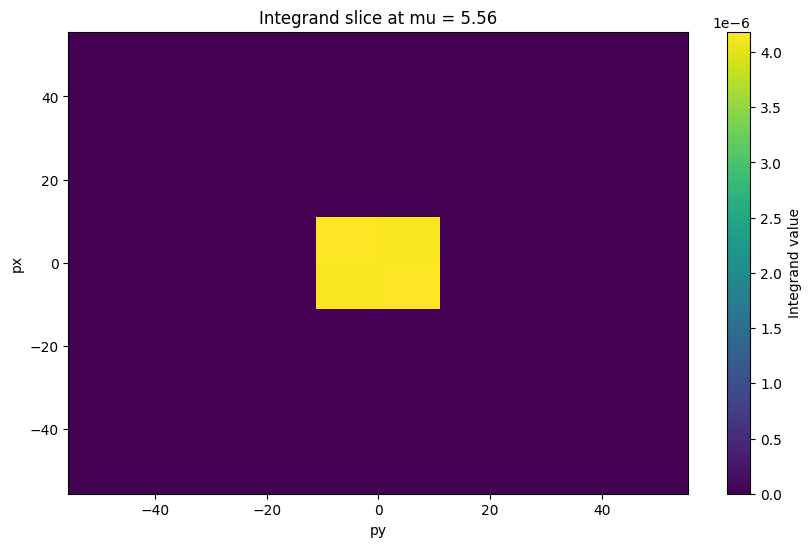

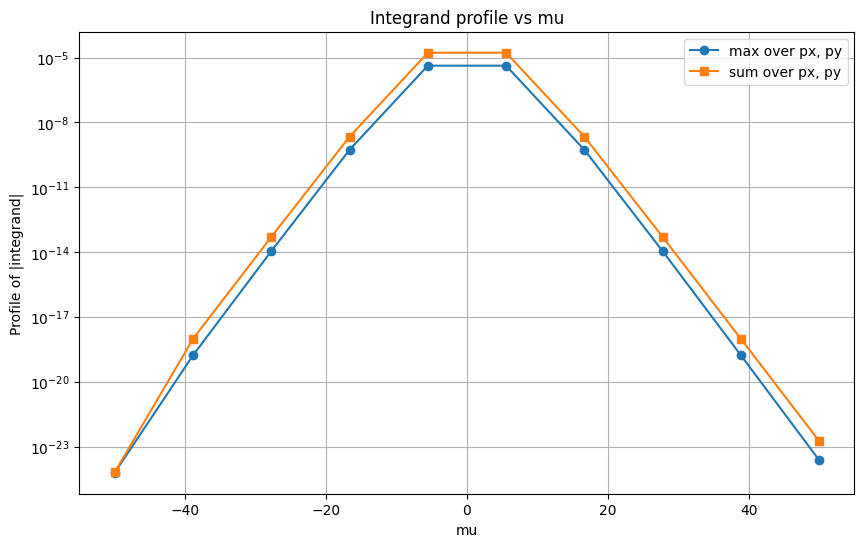

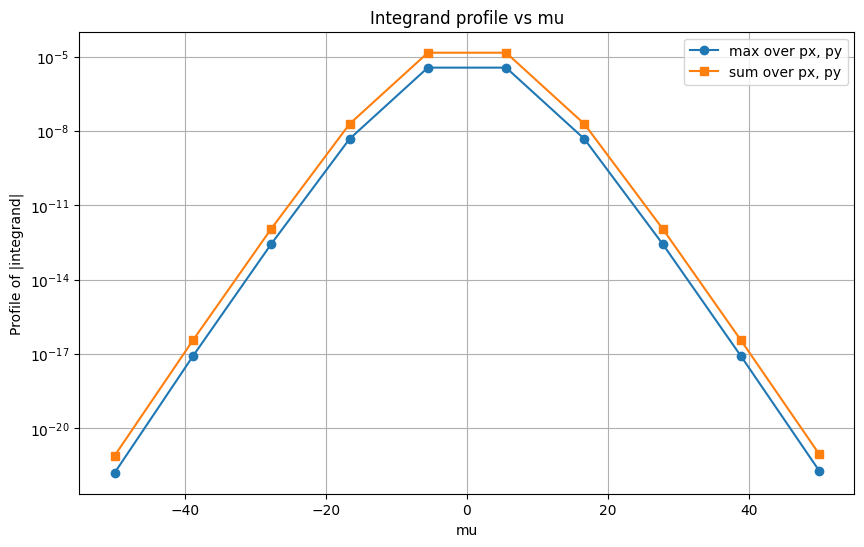

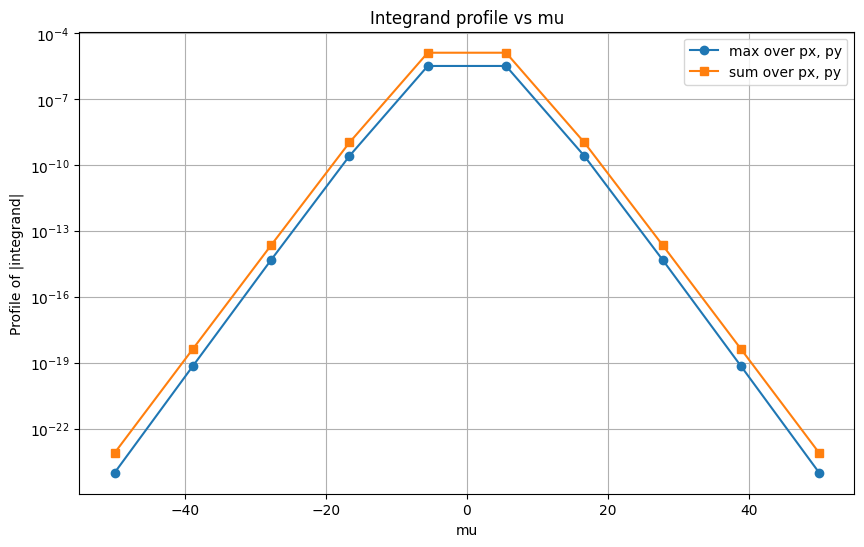

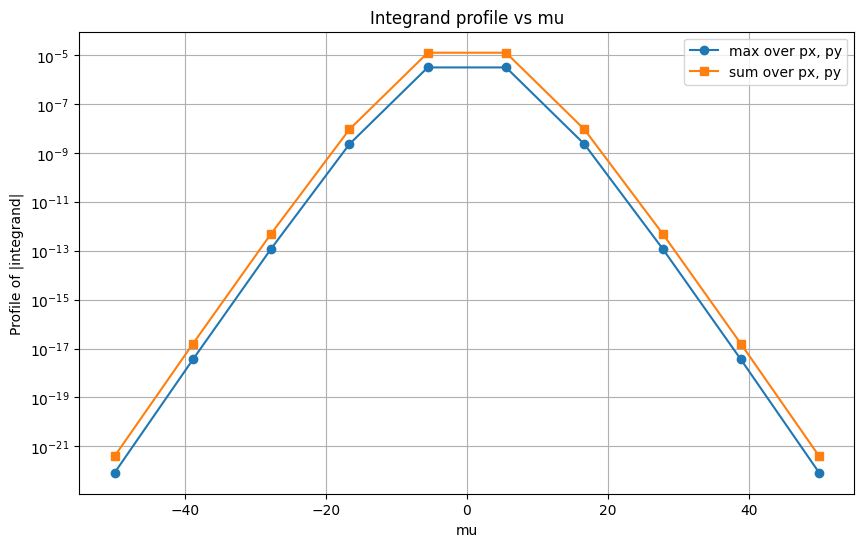

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mu_min, mu_max = -20.0, 20.0
px_min, px_max = -20.0, 20.0
py_min, py_max = -20.0, 20.0

N = 100  # Adjust for speed/resolution

mu_grid = np.linspace(mu_min, mu_max, N)
px_grid = np.linspace(px_min, px_max, N)
py_grid = np.linspace(py_min, py_max, N)

def plot_integrand_slice(integrand_grid, mu_grid, px_grid, py_grid, x_axis='mu', fixed_value=None):
    """
    Plot a 2D slice of the 3D integrand grid.

    Parameters:
    integrand_grid: 3D numpy array of integrand values
    mu_grid, px_grid, py_grid: 1D arrays of grid points
    x_axis: 'mu', 'px', or 'py' to choose which variable is fixed
    fixed_value: value to fix for the chosen dimension (if None, use the middle slice)
    """
    if x_axis == 'mu':
        if fixed_value is None:
            fixed_idx = len(mu_grid) // 2
            fixed_value = mu_grid[fixed_idx]
        else:
            fixed_idx = np.abs(mu_grid - fixed_value).argmin()
            fixed_value = mu_grid[fixed_idx]
        X, Y = np.meshgrid(py_grid, px_grid)
        Z = integrand_grid[fixed_idx, :, :]

    elif x_axis == 'px':
        if fixed_value is None:
            fixed_idx = len(px_grid) // 2
            fixed_value = px_grid[fixed_idx]
        else:
            fixed_idx = np.abs(px_grid - fixed_value).argmin()
            fixed_value = px_grid[fixed_idx]
        X, Y = np.meshgrid(py_grid, mu_grid)
        Z = integrand_grid[:, fixed_idx, :]

    elif x_axis == 'py':
        if fixed_value is None:
            fixed_idx = len(py_grid) // 2
            fixed_value = py_grid[fixed_idx]
        else:
            fixed_idx = np.abs(py_grid - fixed_value).argmin()
            fixed_value = py_grid[fixed_idx]
        X, Y = np.meshgrid(px_grid, mu_grid)
        Z = integrand_grid[:, :, fixed_idx]

    else:
        raise ValueError("x_axis must be 'mu', 'px', or 'py'")

    plt.figure(figsize=(10, 6))
    plt.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')
    plt.colorbar(label='Integrand value')
    plt.xlabel('py' if x_axis in ['mu', 'px'] else 'px')
    plt.ylabel('px' if x_axis == 'mu' else 'mu')
    plt.title(f'Integrand slice at {x_axis} = {fixed_value:.2f}')
    plt.show()

def plot_mu_profile(integrand_grid, mu_grid):
    """
    Plot max and sum of |integrand| over px, py as functions of mu.
    This helps decide a good mu cut.
    """
    mu_profile_max = np.max(np.abs(integrand_grid), axis=(1, 2))
    mu_profile_sum = np.sum(np.abs(integrand_grid), axis=(1, 2))

    plt.figure(figsize=(10, 6))
    plt.plot(mu_grid, mu_profile_max, marker='o', label='max over px, py')
    plt.plot(mu_grid, mu_profile_sum, marker='s', label='sum over px, py')
    plt.yscale('log')
    plt.xlabel('mu')
    plt.ylabel('Profile of |integrand|')
    plt.title('Integrand profile vs mu')
    plt.grid(True)
    plt.legend()
    plt.show()

# EXAMPLES OF HOW TO RUN IT
# integrand_PT_CAN must already be defined as a 3D array with shape (N, N, N)

plot_integrand_slice(integrand_PT_CAN, mu_grid, px_grid, py_grid, x_axis='mu')
plot_mu_profile(integrand_PT_CAN, mu_grid)
plot_mu_profile(integrand_PL_CAN, mu_grid)
plot_mu_profile(integrand_PT_BEL, mu_grid)
plot_mu_profile(integrand_PL_BEL, mu_grid)



In [12]:
import libMilne as MILNE
import numpy as np
import mpmath as mp
from scipy.integrate import simpson

mass = 1.0
tau = 1.0
T= 1
beta = 1/T
Omega= 3
SP = Omega/T
mu_T = 0.0
precision = 215   # same precision for canonical and Belinfante

def eps_mp(tau, mass, mu, px, py):
    tau = mp.mpf(tau)
    mass = mp.mpf(mass)
    mu = mp.mpf(mu)
    px = mp.mpf(px)
    py = mp.mpf(py)
    return mp.sqrt(mass**2 + px**2 + py**2 + mu**2 / tau**2)

def nf_mp(tau, mass, beta, mu, px, py):
    beta = mp.mpf(beta)
    return 1 / (mp.exp(eps_mp(tau, mass, mu, px, py) * beta) + 1)

def PT_bel_integrand(tau, mass, beta, mu, px, py):
    with mp.workdps(precision):
        e = eps_mp(tau, mass, mu, px, py)
        nf = nf_mp(tau, mass, beta, mu, px, py)
        return ((2 * mp.pi) ** (-3) * mp.mpf(tau)) * ((px**2 + py**2) / e) * 2 * nf

def PL_bel_integrand(tau, mass, beta, mu, px, py):
    with mp.workdps(precision):
        e = eps_mp(tau, mass, mu, px, py)
        nf = nf_mp(tau, mass, beta, mu, px, py)
        return ((2 * mp.pi) ** (-3) * mp.mpf(tau)) * (2 * mu**2 / (tau**2 * e)) * 2 * nf

mu_min, mu_max = -30.0, 30.0
px_min, px_max = -30.0, 30.0
py_min, py_max = -30.0, 30.0

N = 10  # Adjust for speed/resolution

mu_grid = np.linspace(mu_min, mu_max, N)
px_grid = np.linspace(px_min, px_max, N)
py_grid = np.linspace(py_min, py_max, N)

integrand_PT_CAN30= np.zeros((N, N, N))
integrand_PT_BEL30 = np.zeros((N, N, N))
integrand_PL_CAN30 = np.zeros((N, N, N))
integrand_PL_BEL30 = np.zeros((N, N, N))

for i, mu in enumerate(mu_grid):
    for j, px in enumerate(px_grid):
        for k, py in enumerate(py_grid):
            integrand_PT_CAN30[i, j, k] = float(
                MILNE.to_numpy(
                    MILNE.tabulating_pressure_T(
                        mass, px, py, mu, tau, beta, SP, mu_T, precision=precision
                    )
                )
            )

            integrand_PT_BEL30[i, j, k] = float(
                PT_bel_integrand(tau, mass, beta, mp.mpf(mu), mp.mpf(px), mp.mpf(py))
            )

            integrand_PL_CAN30[i, j, k] = float(
                MILNE.to_numpy(
                    MILNE.tabulating_pressure_L(
                        mass, px, py, mu, tau, beta, SP, mu_T, precision=precision
                    )
                )
            )

            integrand_PL_BEL30[i, j, k] = float(
                PL_bel_integrand(tau, mass, beta, mp.mpf(mu), mp.mpf(px), mp.mpf(py))
            )

# Canonical
result_PT_mu30 = simpson(integrand_PT_CAN30, x=mu_grid, axis=0)
result_PT_px30 = simpson(result_PT_mu30, x=px_grid, axis=0)
PT_can30 = simpson(result_PT_px30, x=py_grid, axis=0)

result_PL_mu30 = simpson(integrand_PL_CAN30, x=mu_grid, axis=0)
result_PL_px30 = simpson(result_PL_mu30, x=px_grid, axis=0)
PL_can30 = simpson(result_PL_px30, x=py_grid, axis=0)

# Belinfante
class_PT_mu30 = simpson(integrand_PT_BEL30, x=mu_grid, axis=0)
class_PT_px30 = simpson(class_PT_mu30, x=px_grid, axis=0)   # fixed
PT_bel30 = simpson(class_PT_px30, x=py_grid, axis=0)

class_PL_mu30 = simpson(integrand_PL_BEL30, x=mu_grid, axis=0)
class_PL_px30 = simpson(class_PL_mu30, x=px_grid, axis=0)   # fixed
PL_bel30 = simpson(class_PL_px30, x=py_grid, axis=0)

print("Transverse Pressure:")
print("--------------------")
print("Transverse Pressure Belinfante PT_bel:", PT_bel30)
print("Transverse Pressure Canonical PT_can:", PT_can30)
print("Ratio PT_can/PT_bel:", PT_can30 / PT_bel30)

print("\n")
print("Longitudinal Pressure:")
print("--------------------")
print("Longitudinal Pressure Belinfante PL_bel:", PL_bel30)
print("Longitudinal Pressure Canonical PL_can:", PL_can30)
print("Ratio PL_can/PL_bel:", PL_can30 / PL_bel30)

print("\n")
print("Anisotropy Factor:")
print("--------------------")
print("Anisotropy Factor Belinfante PL_bel/PT_bel:", PL_bel30 / PT_bel30)
print("Anisotropy Factor Canonical PL_can/PT_can:", PL_can30 / PT_can30)

print("\n")
print("PL50-PL30:", PL_can-PL_can30)
print("PT50-PT30:", PT_can-PT_can30)
print("PLBel50-PLBel30:", PL_bel-PL_bel30)
print("PTBel50-PTBel30:", PT_bel-PT_bel30)

/var/folders/kj/8tgfcy9s5077xt553nx3by6h0000gn/T/ipykernel_1723/1692228852.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_PT_CAN30[i, j, k] = float(
/var/folders/kj/8tgfcy9s5077xt553nx3by6h0000gn/T/ipykernel_1723/1692228852.py:69: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_PL_CAN30[i, j, k] = float(


Transverse Pressure:
--------------------
Transverse Pressure Belinfante PT_bel: 0.21283687353324582
Transverse Pressure Canonical PT_can: 0.25558768295415407
Ratio PT_can/PT_bel: 1.200861855895616


Longitudinal Pressure:
--------------------
Longitudinal Pressure Belinfante PL_bel: 0.2128368735332458
Longitudinal Pressure Canonical PL_can: 0.1995272312496256
Ratio PL_can/PL_bel: 0.9374655243583007


Anisotropy Factor:
--------------------
Anisotropy Factor Belinfante PL_bel/PT_bel: 0.9999999999999999
Anisotropy Factor Canonical PL_can/PT_can: 0.7806605895222881


PL50-PL30: -0.16020698805363548
PT50-PT30: -0.20992600770932357
PLBel50-PLBel30: -0.17730890632161625
PTBel50-PTBel30: -0.17730890632161628


In [14]:
print("PL rel diff =", abs(PL_can - PL_can30) / abs(PL_can))
print("PT rel diff =", abs(PT_can - PT_can30) / abs(PT_can))
print("PLBel rel diff =", abs(PL_bel - PL_bel30) / abs(PL_bel))
print("PTBel rel diff =", abs(PT_bel - PT_bel30) / abs(PT_bel))

PL rel diff = 4.074414984034825
PT rel diff = 4.597422380666813
PLBel rel diff = 4.990685373735002
PTBel rel diff = 4.990685373735003


In [ ]:
#---------------------------# #---------------------------# #---------------------------# #---------------------------#
#---------------------------# #---------------------------# #---------------------------# #---------------------------#
#---------------------------# #---------------------------# #---------------------------# #---------------------------#
#---------------------------# #---------------------------# #---------------------------# #---------------------------#
#---------------------------# #---------------------------# #---------------------------# #---------------------------#
#---------------------------# #---------------------------# #---------------------------# #---------------------------#
#---------------------------# #---------------------------# #---------------------------# #---------------------------#
#---------------------------# #---------------------------# #---------------------------# #---------------------------#
#---------------------------# #---------------------------# #---------------------------# #---------------------------#
#---------------------------# #---------------------------# #---------------------------# #---------------------------#
#---------------------------# #---------------------------# #---------------------------# #---------------------------#
#---------------------------# #---------------------------# #---------------------------# #---------------------------#
#---------------------------# #---------------------------# #---------------------------# #---------------------------#

In [ ]:
import numpy as np
import mpmath as mp
from scipy.integrate import simpson
import libMilne_FINAL as ml

# ----------------------------
# Parameters
# ----------------------------
mass = 1
tau = 1
T = 1
beta = 1 / T
SP = 1e-5
precision = 40

N = 35   # Simpson works best with odd N
xmin, xmax = -10, 10

px_vals = np.linspace(xmin, xmax, N)
py_vals = np.linspace(xmin, xmax, N)
mu_vals = np.linspace(xmin, xmax, N)

# ----------------------------
# Allocate arrays
# Shape = (N_mu, N_px, N_py)
# ----------------------------
canonical_energy = np.empty((N, N, N), dtype=np.float64)
canonical_transv = np.empty((N, N, N), dtype=np.float64)
canonical_long = np.empty((N, N, N), dtype=np.float64)
canonical_spin = np.empty((N, N, N), dtype=np.float64)
canonical_torque = np.empty((N, N, N), dtype=np.float64)

belinfante_energy = np.empty((N, N, N), dtype=np.float64)
belinfante_transv = np.empty((N, N, N), dtype=np.float64)
belinfante_long = np.empty((N, N, N), dtype=np.float64)

# Optional: track the largest discarded imaginary part
max_imag = {
    "energy": 0.0,
    "transv": 0.0,
    "long": 0.0,
    "spin": 0.0,
    "torque": 0.0,
}

# ----------------------------
# Fill the grid
# ----------------------------
for i_mu, mu in enumerate(mu_vals):
    print(f"Computing slice {i_mu+1}/{N} with mu = {mu:.6f}")
    
    for i_px, px in enumerate(px_vals):
        for i_py, py in enumerate(py_vals):
            # Canonical
            e_c, pt_c, pl_c, s_c, tq_c = ml.tabulating_canonical(
                mass=mass,
                px=px,
                py=py,
                μ=mu,
                τ=tau,
                β=beta,
                SP=SP,
                precision=precision
            )


            # Store only real parts
            canonical_energy[i_mu, i_px, i_py] = float(mp.re(e_c))
            canonical_transv[i_mu, i_px, i_py] = float(mp.re(pt_c))
            canonical_long[i_mu, i_px, i_py]   = float(mp.re(pl_c))
            canonical_spin[i_mu, i_px, i_py]   = float(mp.re(s_c))
            canonical_torque[i_mu, i_px, i_py] = float(mp.re(tq_c))

            # Belinfante
            e_b, pt_b, pl_b = ml.tabulating_belinfante(
                mass=mass,
                px=px,
                py=py,
                μ=mu,
                τ=tau,
                β=beta,
                precision=precision
            )

            belinfante_energy[i_mu, i_px, i_py] = float(e_b)
            belinfante_transv[i_mu, i_px, i_py] = float(pt_b)
            belinfante_long[i_mu, i_px, i_py]   = float(pl_b)

# ----------------------------
# 3D Simpson integration
# integrate in order: py, px, mu
# ----------------------------
def simpson3d(arr, mu_grid, px_grid, py_grid):
    out = simpson(arr, x=py_grid, axis=2)
    out = simpson(out, x=px_grid, axis=1)
    out = simpson(out, x=mu_grid, axis=0)
    return out

I_c_energy = simpson3d(canonical_energy, mu_vals, px_vals, py_vals)
I_c_transv = simpson3d(canonical_transv, mu_vals, px_vals, py_vals)
I_c_long   = simpson3d(canonical_long,   mu_vals, px_vals, py_vals)
I_c_spin   = simpson3d(canonical_spin,   mu_vals, px_vals, py_vals)
I_c_torque = simpson3d(canonical_torque, mu_vals, px_vals, py_vals)

I_b_energy = simpson3d(belinfante_energy, mu_vals, px_vals, py_vals)
I_b_transv = simpson3d(belinfante_transv, mu_vals, px_vals, py_vals)
I_b_long   = simpson3d(belinfante_long,   mu_vals, px_vals, py_vals)

# ----------------------------
# Print final integrated quantities
# ----------------------------
print("\n" + "="*60)
print("Integrated quantities over (mu, px, py) in [-10,10]^3")
print("="*60)

print("\nCanonical:")
print(f"  Energy density          = {I_c_energy:.16e}")
print(f"  Transverse pressure     = {I_c_transv:.16e}")
print(f"  Longitudinal pressure   = {I_c_long:.16e}")
print(f"  Spin density            = {I_c_spin:.16e}")
print(f"  Torque                  = {I_c_torque:.16e}")

print("\nBelinfante:")
print(f"  Energy density          = {I_b_energy:.16e}")
print(f"  Transverse pressure     = {I_b_transv:.16e}")
print(f"  Longitudinal pressure   = {I_b_long:.16e}")


Computing slice 1/35 with mu = -10.000000


ZeroDivisionError: 